In [2]:
import numpy as np
import pandas as pd

In [3]:
from functions import *



df = pd.read_csv("October.csv")
df.head()

,Unnamed: 0,time,open,high,low,close,tick_volume,spread,real_volume
0,0,2022-01-03 01:00:00,1.13753,1.13784,1.13748,1.13782,192,0,0
1,1,2022-01-03 01:05:00,1.13782,1.13782,1.13742,1.13763,119,0,0
2,2,2022-01-03 01:10:00,1.13762,1.13763,1.13728,1.13730,106,0,0
3,3,2022-01-03 01:15:00,1.13729,1.13762,1.13713,1.13718,115,0,0
4,4,2022-01-03 01:20:00,1.13718,1.13721,1.13697,1.13705,44,0,0


In [4]:
del df['Unnamed: 0']

In [5]:
rsi(df)

,time,open,high,low,close,tick_volume,spread,real_volume,RSI
0,2022-01-03 01:00:00,1.13753,1.13784,1.13748,1.13782,192,0,0,NaN
1,2022-01-03 01:05:00,1.13782,1.13782,1.13742,1.13763,119,0,0,0.000000
2,2022-01-03 01:10:00,1.13762,1.13763,1.13728,1.13730,106,0,0,0.000000
3,2022-01-03 01:15:00,1.13729,1.13762,1.13713,1.13718,115,0,0,0.000000
4,2022-01-03 01:20:00,1.13718,1.13721,1.13697,1.13705,44,0,0,0.000000
...,...,...,...,...,...,...,...,...,...
211524,2024-10-30 23:40:00,1.08594,1.08605,1.08593,1.08597,82,0,0,37.068966
211525,2024-10-30 23:45:00,1.08597,1.08598,1.08576,1.08576,140,0,0,30.370370
211526,2024-10-30 23:50:00,1.08576,1.08581,1.08563,1.08563,149,0,0,30.827068
211527,2024-10-30 23:55:00,1.08563,1.08569,1.08550,1.08566,197,0,0,31.343284


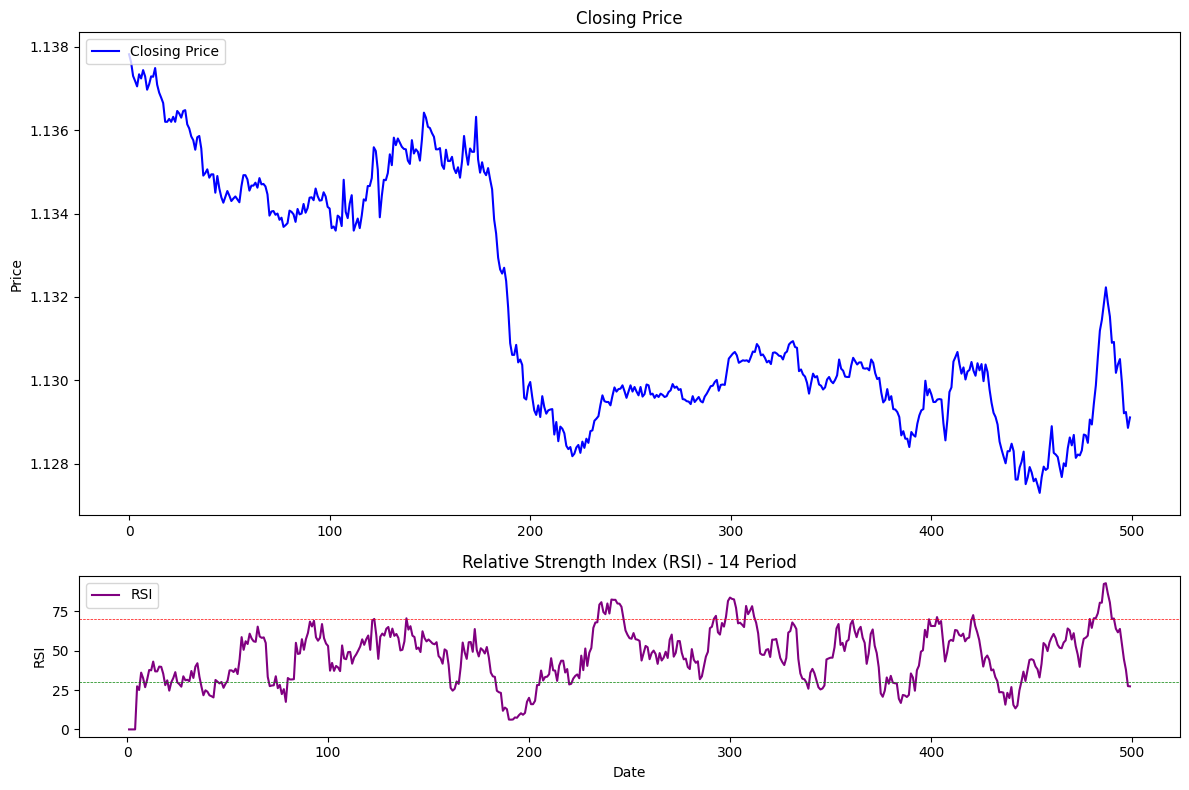

In [6]:
import matplotlib.pyplot as plt

data = df.head(500)
period = 14
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

# Plot the closing price on the first subplot
ax1.plot(data['close'], color='blue', label='Closing Price')
ax1.set_title('Closing Price')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')

# Plot the RSI on the second subplot
ax2.plot(data['RSI'], color='purple', label='RSI')
ax2.axhline(70, color='red', linestyle='--', linewidth=0.5)  # Overbought line
ax2.axhline(30, color='green', linestyle='--', linewidth=0.5)  # Oversold line
ax2.set_title(f'Relative Strength Index (RSI) - {period} Period')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.legend(loc='upper left')

# Show plot
plt.tight_layout()
plt.show()

In [7]:
df

,time,open,high,low,close,tick_volume,spread,real_volume,RSI
0,2022-01-03 01:00:00,1.13753,1.13784,1.13748,1.13782,192,0,0,NaN
1,2022-01-03 01:05:00,1.13782,1.13782,1.13742,1.13763,119,0,0,0.000000
2,2022-01-03 01:10:00,1.13762,1.13763,1.13728,1.13730,106,0,0,0.000000
3,2022-01-03 01:15:00,1.13729,1.13762,1.13713,1.13718,115,0,0,0.000000
4,2022-01-03 01:20:00,1.13718,1.13721,1.13697,1.13705,44,0,0,0.000000
...,...,...,...,...,...,...,...,...,...
211524,2024-10-30 23:40:00,1.08594,1.08605,1.08593,1.08597,82,0,0,37.068966
211525,2024-10-30 23:45:00,1.08597,1.08598,1.08576,1.08576,140,0,0,30.370370
211526,2024-10-30 23:50:00,1.08576,1.08581,1.08563,1.08563,149,0,0,30.827068
211527,2024-10-30 23:55:00,1.08563,1.08569,1.08550,1.08566,197,0,0,31.343284


In [8]:
from functions import *

df = calculate_macd(df)

In [9]:
def add_time_features(df, time_column):
    """
    Adds time-based columns to a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame containing a datetime column.
    time_column (str): The name of the column with datetime data.
    
    Returns:
    pd.DataFrame: The DataFrame with new time-based columns.
    """
    # Ensure the time_column is in datetime format
    df[time_column] = pd.to_datetime(df[time_column], errors='coerce')

    # Extract time features
    df['minute'] = df[time_column].dt.minute
    df['hour'] = df[time_column].dt.hour
    df['day'] = df[time_column].dt.day
    df['month'] = df[time_column].dt.month
    df['year'] = df[time_column].dt.year

    return df

In [10]:
df = add_time_features(df,'time')
df.head()

,time,open,high,low,close,tick_volume,spread,real_volume,RSI,ema_short,ema_long,MACD,signal_line,MACD_histogram,minute,hour,day,month,year
0,2022-01-03 01:00:00,1.13753,1.13784,1.13748,1.13782,192,0,0,NaN,1.137820,1.137820,0.000000,0.000000,0.000000,0,1,3,1,2022
1,2022-01-03 01:05:00,1.13782,1.13782,1.13742,1.13763,119,0,0,0.0,1.137791,1.137806,-0.000015,-0.000003,-0.000012,5,1,3,1,2022
2,2022-01-03 01:10:00,1.13762,1.13763,1.13728,1.13730,106,0,0,0.0,1.137715,1.137768,-0.000053,-0.000013,-0.000040,10,1,3,1,2022
3,2022-01-03 01:15:00,1.13729,1.13762,1.13713,1.13718,115,0,0,0.0,1.137633,1.137725,-0.000092,-0.000029,-0.000063,15,1,3,1,2022
4,2022-01-03 01:20:00,1.13718,1.13721,1.13697,1.13705,44,0,0,0.0,1.137543,1.137675,-0.000132,-0.000049,-0.000082,20,1,3,1,2022


In [11]:
def generate_macd_signals(df):
    """
    Adds a 'signal' column to the DataFrame based on MACD strategy.
    
    Parameters:
        df (pd.DataFrame): A DataFrame containing the MACD line, Signal line, and other columns.
    
    Returns:
        pd.DataFrame: The input DataFrame with an additional 'signal' column.
    """
    # Initialize the 'signal' column with 0 (no signal)
    df['Signal'] = 0

    # Generate buy (1) and sell (-1) signals
    for i in range(1, len(df)):
        # Bullish crossover (Buy)
        if df.loc[i, 'MACD'] > df.loc[i, 'signal_line'] and df.loc[i - 1, 'MACD'] <= df.loc[i - 1, 'signal_line']:
            df.loc[i, 'Signal'] = 1

        # Bearish crossover (Sell)
        elif df.loc[i, 'MACD'] < df.loc[i, 'signal_line'] and df.loc[i - 1, 'MACD'] >= df.loc[i - 1, 'signal_line']:
            df.loc[i, 'Signal'] = -1

    return df

In [12]:
df = generate_macd_signals(df)

In [13]:
import pandas as pd

def add_next_close_price_on_signal(df):
    """
    Adds a new column to the DataFrame with the close price of the next signal (1 or -1).
    Sets next_close to 0 if the current signal is 0.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame with 'close' and 'Signal' columns.
    
    Returns:
    pd.DataFrame: The DataFrame with the new column 'next_close'.
    """
    # Initialize a new column
    df['next_close'] = None
    
    # Loop through the DataFrame to find the next signal's close price
    for i in range(len(df)):
        if df.at[i, 'Signal'] == 0:
            df.at[i, 'next_close'] = 0  # Set next_close to 0 if Signal is 0
        elif df.at[i, 'Signal'] in [1, -1]:  # Check for buy or sell signal
            # Find the next row with either a 1 or -1 signal
            for j in range(i + 1, len(df)):
                if df.at[j, 'Signal'] in [1, -1]:
                    df.at[i, 'next_close'] = df.at[j, 'close']
                    break  # Exit the inner loop once the next signal is found

    return df

In [14]:
df = add_next_close_price_on_signal(df)

In [15]:
df.head()

,time,open,high,low,close,tick_volume,spread,real_volume,RSI,ema_short,...,MACD,signal_line,MACD_histogram,minute,hour,day,month,year,Signal,next_close
0,2022-01-03 01:00:00,1.13753,1.13784,1.13748,1.13782,192,0,0,NaN,1.137820,...,0.000000,0.000000,0.000000,0,1,3,1,2022,0,0
1,2022-01-03 01:05:00,1.13782,1.13782,1.13742,1.13763,119,0,0,0.0,1.137791,...,-0.000015,-0.000003,-0.000012,5,1,3,1,2022,-1,1.13749
2,2022-01-03 01:10:00,1.13762,1.13763,1.13728,1.13730,106,0,0,0.0,1.137715,...,-0.000053,-0.000013,-0.000040,10,1,3,1,2022,0,0
3,2022-01-03 01:15:00,1.13729,1.13762,1.13713,1.13718,115,0,0,0.0,1.137633,...,-0.000092,-0.000029,-0.000063,15,1,3,1,2022,0,0
4,2022-01-03 01:20:00,1.13718,1.13721,1.13697,1.13705,44,0,0,0.0,1.137543,...,-0.000132,-0.000049,-0.000082,20,1,3,1,2022,0,0


In [16]:
df = df[(df['Signal'] != 0)]


In [17]:
df['Profit'] = df['close'] - df['next_close']
df['Profit'] = np.where(df['Signal'] == 1, df['Profit'] * -1, df['Profit'])

C:\Users\hevar\AppData\Local\Temp\ipykernel_3752\1292643832.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Profit'] = df['close'] - df['next_close']
C:\Users\hevar\AppData\Local\Temp\ipykernel_3752\1292643832.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Profit'] = np.where(df['Signal'] == 1, df['Profit'] * -1, df['Profit'])


In [18]:
import numpy as np

# Categorize Profit: 0 for negative, 1 for non-negative
df['Profit Cat'] = np.where(df['Profit'] < 0, 0, 1)


C:\Users\hevar\AppData\Local\Temp\ipykernel_3752\1817847379.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Profit Cat'] = np.where(df['Profit'] < 0, 0, 1)


In [19]:
df.head()

,time,open,high,low,close,tick_volume,spread,real_volume,RSI,ema_short,...,MACD_histogram,minute,hour,day,month,year,Signal,next_close,Profit,Profit Cat
1,2022-01-03 01:05:00,1.13782,1.13782,1.13742,1.13763,119,0,0,0.000000,1.137791,...,-0.000012,5,1,3,1,2022,-1,1.13749,0.00014,1
13,2022-01-03 02:05:00,1.13726,1.13757,1.13725,1.13749,76,0,0,43.037975,1.137341,...,0.000007,5,2,3,1,2022,1,1.13709,-0.0004,0
14,2022-01-03 02:10:00,1.13749,1.13753,1.13706,1.13709,55,0,0,36.823105,1.137302,...,-0.000003,10,2,3,1,2022,-1,1.13646,0.00063,1
27,2022-01-03 03:15:00,1.13629,1.13646,1.13600,1.13646,94,0,0,27.111111,1.136478,...,0.000011,15,3,3,1,2022,1,1.13585,-0.00061,0
31,2022-01-03 03:35:00,1.13605,1.13610,1.13575,1.13585,84,0,0,30.582524,1.136287,...,-0.000012,35,3,3,1,2022,-1,1.13443,0.00142,1


In [20]:
df_filtered = df

In [21]:
df_filtered.reset_index(inplace=True)
del df_filtered['index']

In [22]:
df_filtered.dropna(inplace=True)

C:\Users\hevar\AppData\Local\Temp\ipykernel_3752\208647654.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.dropna(inplace=True)


In [23]:
df_filtered.head(50)

,time,open,high,low,close,tick_volume,spread,real_volume,RSI,ema_short,...,MACD_histogram,minute,hour,day,month,year,Signal,next_close,Profit,Profit Cat
0,2022-01-03 01:05:00,1.13782,1.13782,1.13742,1.13763,119,0,0,0.000000,1.137791,...,-1.212536e-05,5,1,3,1,2022,-1,1.13749,0.00014,1
1,2022-01-03 02:05:00,1.13726,1.13757,1.13725,1.13749,76,0,0,43.037975,1.137341,...,6.868922e-06,5,2,3,1,2022,1,1.13709,-0.0004,0
2,2022-01-03 02:10:00,1.13749,1.13753,1.13706,1.13709,55,0,0,36.823105,1.137302,...,-2.579574e-06,10,2,3,1,2022,-1,1.13646,0.00063,1
3,2022-01-03 03:15:00,1.13629,1.13646,1.13600,1.13646,94,0,0,27.111111,1.136478,...,1.083568e-05,15,3,3,1,2022,1,1.13585,-0.00061,0
4,2022-01-03 03:35:00,1.13605,1.13610,1.13575,1.13585,84,0,0,30.582524,1.136287,...,-1.183027e-05,35,3,3,1,2022,-1,1.13443,0.00142,1
5,2022-01-03 05:10:00,1.13454,1.13454,1.13432,1.13443,37,0,0,30.847458,1.134696,...,2.005080e-06,10,5,3,1,2022,1,1.13395,-0.00048,0
6,2022-01-03 06:50:00,1.13447,1.13447,1.13395,1.13395,108,0,0,33.333333,1.134543,...,-4.266135e-06,50,6,3,1,2022,-1,1.13404,-0.00009,0
7,2022-01-03 07:45:00,1.13408,1.13410,1.13386,1.13404,58,0,0,31.693989,1.134012,...,1.143273e-05,45,7,3,1,2022,1,1.13365,-0.00039,0
8,2022-01-03 09:25:00,1.13412,1.13413,1.13364,1.13365,83,0,0,37.280702,1.134179,...,-3.344038e-05,25,9,3,1,2022,-1,1.13481,-0.00116,0
9,2022-01-03 09:55:00,1.13370,1.13501,1.13368,1.13481,333,0,0,53.271028,1.134084,...,2.298611e-05,55,9,3,1,2022,1,1.13359,-0.00122,0


In [24]:
df_filtered['Profit Cat'].value_counts()

Profit Cat
0    11461
1     5659
Name: count, dtype: int64

In [25]:
df_filtered

,time,open,high,low,close,tick_volume,spread,real_volume,RSI,ema_short,...,MACD_histogram,minute,hour,day,month,year,Signal,next_close,Profit,Profit Cat
0,2022-01-03 01:05:00,1.13782,1.13782,1.13742,1.13763,119,0,0,0.000000,1.137791,...,-1.212536e-05,5,1,3,1,2022,-1,1.13749,0.00014,1
1,2022-01-03 02:05:00,1.13726,1.13757,1.13725,1.13749,76,0,0,43.037975,1.137341,...,6.868922e-06,5,2,3,1,2022,1,1.13709,-0.0004,0
2,2022-01-03 02:10:00,1.13749,1.13753,1.13706,1.13709,55,0,0,36.823105,1.137302,...,-2.579574e-06,10,2,3,1,2022,-1,1.13646,0.00063,1
3,2022-01-03 03:15:00,1.13629,1.13646,1.13600,1.13646,94,0,0,27.111111,1.136478,...,1.083568e-05,15,3,3,1,2022,1,1.13585,-0.00061,0
4,2022-01-03 03:35:00,1.13605,1.13610,1.13575,1.13585,84,0,0,30.582524,1.136287,...,-1.183027e-05,35,3,3,1,2022,-1,1.13443,0.00142,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17115,2024-10-30 16:00:00,1.08141,1.08199,1.08136,1.08179,457,0,0,44.570136,1.081647,...,1.337905e-05,0,16,30,10,2024,1,1.08444,0.00265,1
17116,2024-10-30 18:00:00,1.08491,1.08502,1.08438,1.08444,416,0,0,56.144578,1.084750,...,-2.566767e-05,0,18,30,10,2024,-1,1.08602,-0.00158,0
17117,2024-10-30 18:35:00,1.08577,1.08603,1.08566,1.08602,297,0,0,66.408269,1.085398,...,7.267173e-07,35,18,30,10,2024,1,1.08628,0.00026,1
17118,2024-10-30 19:00:00,1.08638,1.08657,1.08605,1.08628,387,0,0,66.774194,1.085939,...,-5.665272e-07,0,19,30,10,2024,-1,1.08679,-0.00051,0


In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [27]:
df= df_filtered

In [28]:
fff = df.drop(['time'], axis=1)

In [29]:
fff

,open,high,low,close,tick_volume,spread,real_volume,RSI,ema_short,ema_long,...,MACD_histogram,minute,hour,day,month,year,Signal,next_close,Profit,Profit Cat
0,1.13782,1.13782,1.13742,1.13763,119,0,0,0.000000,1.137791,1.137806,...,-1.212536e-05,5,1,3,1,2022,-1,1.13749,0.00014,1
1,1.13726,1.13757,1.13725,1.13749,76,0,0,43.037975,1.137341,1.137475,...,6.868922e-06,5,2,3,1,2022,1,1.13709,-0.0004,0
2,1.13749,1.13753,1.13706,1.13709,55,0,0,36.823105,1.137302,1.137446,...,-2.579574e-06,10,2,3,1,2022,-1,1.13646,0.00063,1
3,1.13629,1.13646,1.13600,1.13646,94,0,0,27.111111,1.136478,1.136776,...,1.083568e-05,15,3,3,1,2022,1,1.13585,-0.00061,0
4,1.13605,1.13610,1.13575,1.13585,84,0,0,30.582524,1.136287,1.136599,...,-1.183027e-05,35,3,3,1,2022,-1,1.13443,0.00142,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17115,1.08141,1.08199,1.08136,1.08179,457,0,0,44.570136,1.081647,1.082146,...,1.337905e-05,0,16,30,10,2024,1,1.08444,0.00265,1
17116,1.08491,1.08502,1.08438,1.08444,416,0,0,56.144578,1.084750,1.084085,...,-2.566767e-05,0,18,30,10,2024,-1,1.08602,-0.00158,0
17117,1.08577,1.08603,1.08566,1.08602,297,0,0,66.408269,1.085398,1.084735,...,7.267173e-07,35,18,30,10,2024,1,1.08628,0.00026,1
17118,1.08638,1.08657,1.08605,1.08628,387,0,0,66.774194,1.085939,1.085253,...,-5.665272e-07,0,19,30,10,2024,-1,1.08679,-0.00051,0


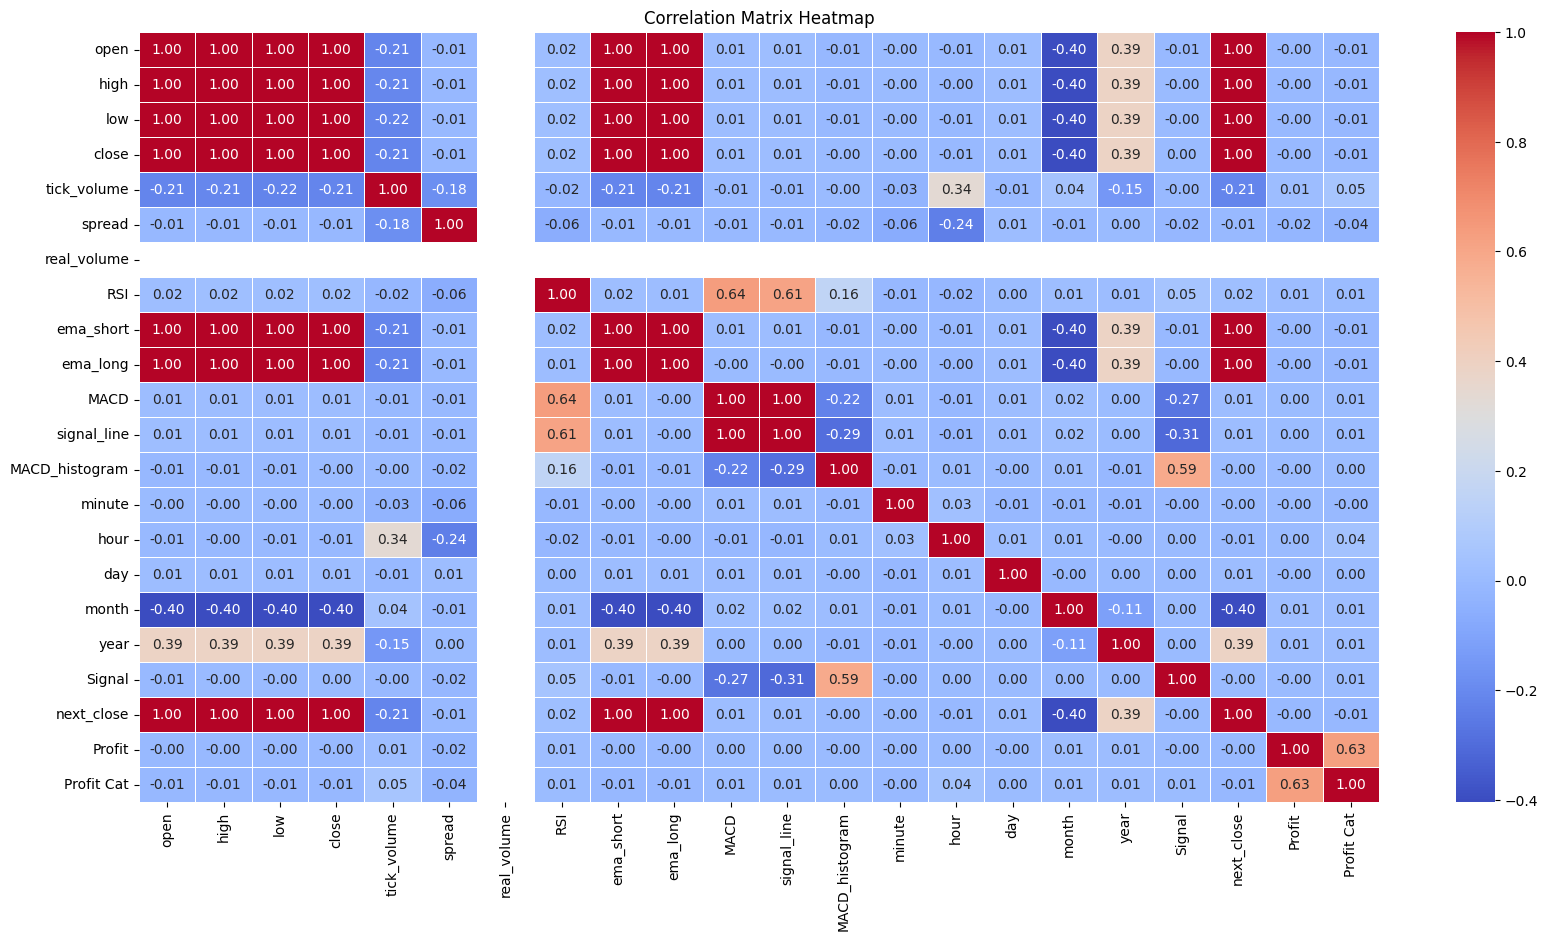

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data
# df = pd.read_csv('your_dataset.csv')

# Calculate the correlation matrix
correlation_matrix = fff.corr()

# Set up the matplotlib figure
plt.figure(figsize=(20, 10))

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Customize plot labels
plt.title("Correlation Matrix Heatmap")
plt.show()


In [31]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Sample data
# df = pd.read_csv('your_dataset.csv')

df_alt = df[['open','high','low','close','ema_short','ema_long','next_close']]

# Step 1: Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_alt)

# Step 2: Apply PCA
# Set the number of components you want to retain (e.g., 2 or enough to explain 95% variance)
pca = PCA(n_components=0.95)  # Retain 95% of the variance
principal_components = pca.fit_transform(scaled_data)

# Convert the result to a DataFrame for easier handling
principal_df = pd.DataFrame(data=principal_components, columns=[f"PC{i+1}" for i in range(principal_components.shape[1])])

# Explained variance
explained_variance = pca.explained_variance_ratio_
print("Explained variance by each principal component:", explained_variance)

# Resulting DataFrame with Principal Components
print(principal_df.head())


Explained variance by each principal component: [0.99981498]
        PC1
0  4.808261
1  4.783633
2  4.771892
3  4.706979
4  4.672219


In [32]:
principal_df

,PC1
0,4.808261
1,4.783633
2,4.771892
3,4.706979
4,4.672219
...,...
17115,0.644685
17116,0.846139
17117,0.913437
17118,0.949500


In [33]:
df['PCA'] = principal_df['PC1']

C:\Users\hevar\AppData\Local\Temp\ipykernel_3752\3247566773.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['PCA'] = principal_df['PC1']


In [34]:
df

,time,open,high,low,close,tick_volume,spread,real_volume,RSI,ema_short,...,minute,hour,day,month,year,Signal,next_close,Profit,Profit Cat,PCA
0,2022-01-03 01:05:00,1.13782,1.13782,1.13742,1.13763,119,0,0,0.000000,1.137791,...,5,1,3,1,2022,-1,1.13749,0.00014,1,4.808261
1,2022-01-03 02:05:00,1.13726,1.13757,1.13725,1.13749,76,0,0,43.037975,1.137341,...,5,2,3,1,2022,1,1.13709,-0.0004,0,4.783633
2,2022-01-03 02:10:00,1.13749,1.13753,1.13706,1.13709,55,0,0,36.823105,1.137302,...,10,2,3,1,2022,-1,1.13646,0.00063,1,4.771892
3,2022-01-03 03:15:00,1.13629,1.13646,1.13600,1.13646,94,0,0,27.111111,1.136478,...,15,3,3,1,2022,1,1.13585,-0.00061,0,4.706979
4,2022-01-03 03:35:00,1.13605,1.13610,1.13575,1.13585,84,0,0,30.582524,1.136287,...,35,3,3,1,2022,-1,1.13443,0.00142,1,4.672219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17115,2024-10-30 16:00:00,1.08141,1.08199,1.08136,1.08179,457,0,0,44.570136,1.081647,...,0,16,30,10,2024,1,1.08444,0.00265,1,0.644685
17116,2024-10-30 18:00:00,1.08491,1.08502,1.08438,1.08444,416,0,0,56.144578,1.084750,...,0,18,30,10,2024,-1,1.08602,-0.00158,0,0.846139
17117,2024-10-30 18:35:00,1.08577,1.08603,1.08566,1.08602,297,0,0,66.408269,1.085398,...,35,18,30,10,2024,1,1.08628,0.00026,1,0.913437
17118,2024-10-30 19:00:00,1.08638,1.08657,1.08605,1.08628,387,0,0,66.774194,1.085939,...,0,19,30,10,2024,-1,1.08679,-0.00051,0,0.949500


In [35]:
import pandas as pd
import numpy as np

# Assuming df is your original DataFrame
# Define the feature columns and the target column
feature_columns = ['PCA','RSI', 'Signal','MACD','signal_line','MACD_histogram','month','hour','minute','day','year']  # List of feature columns
target_column = 'Profit Cat'  # Target column


In [36]:
df.columns

Index(['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread',
       'real_volume', 'RSI', 'ema_short', 'ema_long', 'MACD', 'signal_line',
       'MACD_histogram', 'minute', 'hour', 'day', 'month', 'year', 'Signal',
       'next_close', 'Profit', 'Profit Cat', 'PCA'],
      dtype='object')

In [37]:
feature_columns.append(target_column)
feature_columns

['PCA',
 'RSI',
 'Signal',
 'MACD',
 'signal_line',
 'MACD_histogram',
 'month',
 'hour',
 'minute',
 'day',
 'year',
 'Profit Cat']

In [38]:
df = df[feature_columns]

In [39]:
df.head(10)

,PCA,RSI,Signal,MACD,signal_line,MACD_histogram,month,hour,minute,day,year,Profit Cat
0,4.808261,0.000000,-1,-0.000015,-0.000003,-0.000012,1,1,5,3,2022,1
1,4.783633,43.037975,1,-0.000134,-0.000141,0.000007,1,2,5,3,2022,0
2,4.771892,36.823105,-1,-0.000144,-0.000141,-0.000003,1,2,10,3,2022,1
3,4.706979,27.111111,1,-0.000298,-0.000309,0.000011,1,3,15,3,2022,0
4,4.672219,30.582524,-1,-0.000312,-0.000300,-0.000012,1,3,35,3,2022,1
5,4.571723,30.847458,1,-0.000505,-0.000507,0.000002,1,5,10,3,2022,0
6,4.555187,33.333333,-1,-0.000166,-0.000162,-0.000004,1,6,50,3,2022,0
7,4.532321,31.693989,1,-0.000242,-0.000253,0.000011,1,7,45,3,2022,0
8,4.540339,37.280702,-1,-0.000038,-0.000005,-0.000033,1,9,25,3,2022,0
9,4.543110,53.271028,1,-0.000046,-0.000069,0.000023,1,9,55,3,2022,0


In [40]:
df['Profit Cat'].value_counts()

Profit Cat
0    11461
1     5659
Name: count, dtype: int64

In [41]:
# # Determine the split index
# split_index = int(0.8 * len(df))

# # Sequential split
# xTrain = df[:split_index]
# xTest = df[split_index:]

# yTrain = xTrain[['Profit Cat']]
# yTest = xTest[['Profit Cat']]

# xTrain.drop("Profit Cat", axis=1, inplace=True)
# xTest.drop("Profit Cat", axis=1, inplace=True)

In [42]:
from sklearn.model_selection import train_test_split
feature_columns = ['PCA','RSI', 'Signal','MACD','signal_line','MACD_histogram','month','hour','minute','day','year']  # List of feature columns
target_column = 'Profit Cat'  # Target column

xTrain, xTest, yTrain, yTest = train_test_split(df[feature_columns],df[[target_column]],test_size=0.2,random_state=42)

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [45]:
xTrain

,PCA,RSI,Signal,MACD,signal_line,MACD_histogram,month,hour,minute,day,year
10071,0.699723,63.030303,1,0.000192,0.000187,4.591509e-06,8,3,10,29,2023
1740,0.592895,34.500000,-1,-0.000246,-0.000243,-3.752470e-06,4,3,50,15,2022
1957,-1.657223,48.841699,1,-0.000678,-0.000682,4.368220e-06,4,7,30,28,2022
16642,2.494544,44.274809,-1,0.000024,0.000066,-4.203434e-05,10,15,15,2,2024
6835,-0.065326,57.189542,1,0.000290,0.000289,9.566999e-07,2,12,5,15,2023
...,...,...,...,...,...,...,...,...,...,...,...
11284,-0.474654,44.444444,-1,0.000101,0.000124,-2.275083e-05,11,14,15,8,2023
11964,1.434590,54.970760,-1,0.000065,0.000071,-5.591984e-06,12,9,0,19,2023
5390,-2.705346,50.710900,-1,0.000142,0.000145,-3.435580e-06,11,14,40,18,2022
860,4.523633,64.928910,-1,0.000201,0.000202,-6.601108e-07,2,19,30,21,2022


In [46]:

model = RandomForestClassifier(n_estimators=500,random_state=42,class_weight='balanced',min_samples_leaf=5,max_features='sqrt',min_samples_split=2)

model.fit(xTrain,yTrain)

c:\Users\hevar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       n_estimators=500, random_state=42)

In [47]:
from sklearn.metrics import classification_report
y_pred = model.predict(xTest)

print(classification_report(yTest,y_pred))

              precision    recall  f1-score   support

           0       0.66      0.85      0.74      2253
           1       0.36      0.16      0.22      1171

    accuracy                           0.61      3424
   macro avg       0.51      0.51      0.48      3424
weighted avg       0.56      0.61      0.56      3424



In [48]:
import joblib


filename = 'macd_model.sav'
joblib.dump(model, open(filename, 'wb')) 
  
# load the model 
load_model = joblib.load(open(filename, 'rb')) 